In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
data_3d_simple = np.loadtxt("./data/3d_data_simple.csv", delimiter=",")

data_times = data_3d_simple[:, 0]
data_position_means_si  = data_3d_simple[:, 1:4]    # [m]
data_position_sigmas_si = data_3d_simple[:, 4:7]    # [m]
data_momentum_means_pp  = data_3d_simple[:, 7:10]   # [MeV/c]
data_momentum_sigmas_pp = data_3d_simple[:, 10:]    # [MeV/c]

<>:106: SyntaxWarning: invalid escape sequence '\e'
<>:107: SyntaxWarning: invalid escape sequence '\e'
<>:108: SyntaxWarning: invalid escape sequence '\e'
<>:110: SyntaxWarning: invalid escape sequence '\e'
<>:106: SyntaxWarning: invalid escape sequence '\e'
<>:107: SyntaxWarning: invalid escape sequence '\e'
<>:108: SyntaxWarning: invalid escape sequence '\e'
<>:110: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Alex\AppData\Local\Temp\ipykernel_32668\2423066783.py:106: SyntaxWarning: invalid escape sequence '\e'
  axes[1].plot(t, eps_long, 'b-', label='$\epsilon_{longitudinal}$')
C:\Users\Alex\AppData\Local\Temp\ipykernel_32668\2423066783.py:107: SyntaxWarning: invalid escape sequence '\e'
  axes[1].plot(t, eps_trans, 'r-', label='$\epsilon_{transversal}$')
C:\Users\Alex\AppData\Local\Temp\ipykernel_32668\2423066783.py:108: SyntaxWarning: invalid escape sequence '\e'
  axes[1].axhline(1.0, color='k', linestyle=':', label='Störungs-Grenze ($\epsilon = 1$)')
C:\Users\Alex\AppDa

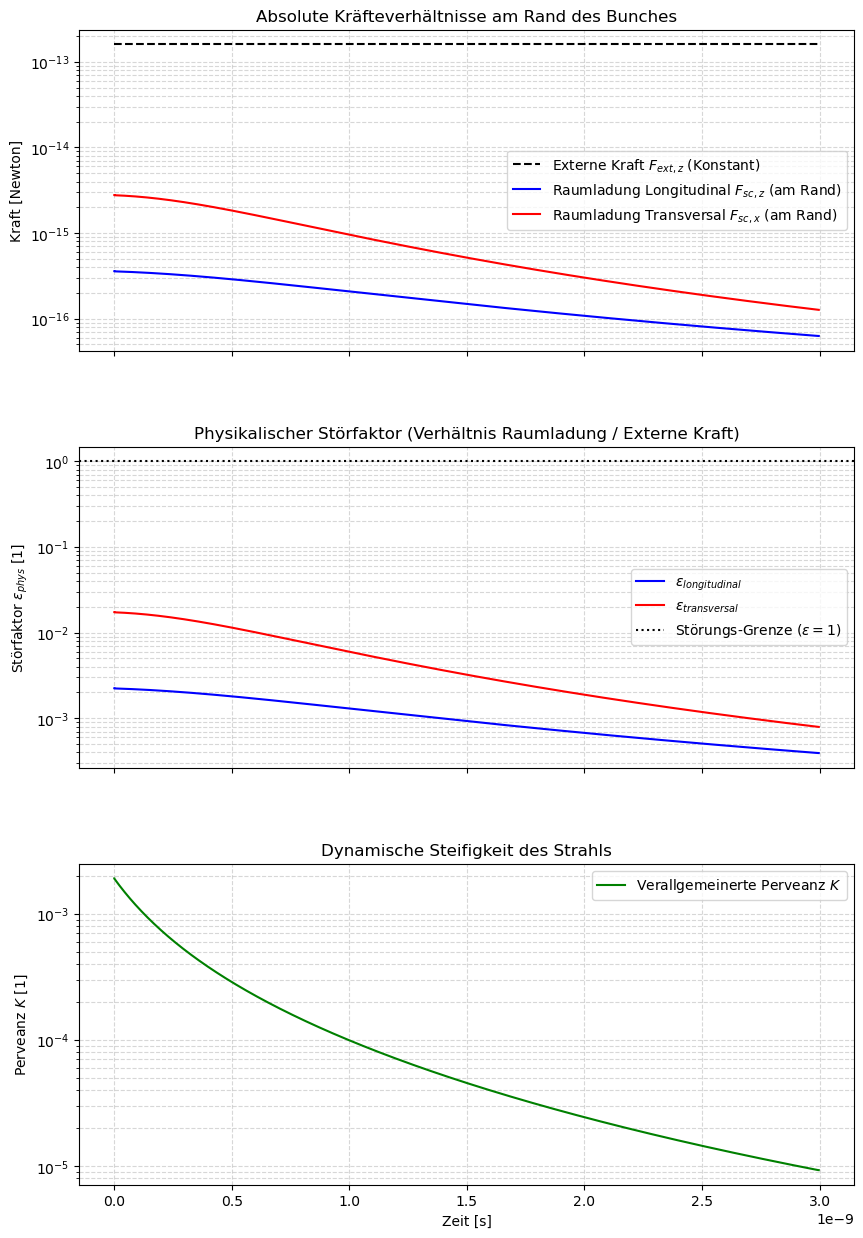

In [12]:
# =============================================================================
# 1. Konstanten & Parameter (SI-Einheiten für saubere analytische Berechnung)
# =============================================================================
E_Z = -1.0 # MV/m
TOTAL_CHARGE_SI = -1e-9 # C 
M_E_SI = 9.1093837015e-31 # kg
Q_E_SI = -1.602176634e-19 # C
C_SI = 299792458 # m/s
M_E_MEV = 0.511 # MeV/c^2
EPSILON_0_SI = 8.8541878128e-12 # C/(V*m) - Standard SI für L-W und Poisson

# =============================================================================
# 2. Daten extrahieren (Nimmt an, dass Arrays bereits im Workspace liegen)
# =============================================================================
t = data_times
sigma_x = data_position_sigmas_si[:, 0]
sigma_y = data_position_sigmas_si[:, 1]
sigma_z = data_position_sigmas_si[:, 2]

# Wir nehmen den absoluten Impuls in z-Richtung für die Kinematik
pz_mev = np.abs(data_momentum_means_pp[:, 2])

# =============================================================================
# 3. Relativistische Kinematik
# =============================================================================
# Impuls in dimensionsloses beta*gamma umrechnen
beta_gamma = pz_mev / M_E_MEV
gamma = np.sqrt(1.0 + beta_gamma**2)
beta = beta_gamma / gamma
v_z = beta * C_SI

# =============================================================================
# 4. Geometrie des Uniformen Ellipsoids
# =============================================================================
# Die wahren Ränder R_i eines uniformen Ellipsoids sind sqrt(5) * rms_i
R_x = np.sqrt(5.0) * sigma_x
R_y = np.sqrt(5.0) * sigma_y
R_z = np.sqrt(5.0) * sigma_z
R_perp = (R_x + R_y) / 2.0 # Mittlerer transversaler Radius

# =============================================================================
# 5. Berechnung der Perveanz (K)
# =============================================================================
# Alfvén-Strom für Elektronen (~ 17.045 kA)
I_A = (4.0 * np.pi * EPSILON_0_SI * M_E_SI * C_SI**3) / np.abs(Q_E_SI)

# Effektiver Strom des Bunches: I = Q * v / L_bunch (wobei L_bunch = 2 * R_z)
I_bunch = (np.abs(TOTAL_CHARGE_SI) * v_z) / (2.0 * R_z)

# Perveanz (dimensionslos)
K = (I_bunch / I_A) * (2.0 / (beta**3 * gamma**3))

# =============================================================================
# 6. Externe Kraft
# =============================================================================
# Externe Kraft in [Newton]
E_ext_SI = np.abs(E_Z) * 1e6 # 1 MV/m = 10^6 V/m
F_ext = np.abs(Q_E_SI) * E_ext_SI

# =============================================================================
# 7. Raumladungskräfte (Poisson-Lösung am Rand des Ellipsoids)
# =============================================================================
# a) Longitudinaler Formfaktor g_z im Lorentz-transformierten Ruhesystem
# Ein Bunch der Länge R_z im Laborsystem ist im Ruhesystem gamma * R_z lang.
gamma_R_z = gamma * R_z
aspect_ratio = gamma_R_z / R_perp

# Näherungsformel für g_z für langgezogene Ellipsoide (aspect_ratio > 1)
g_z = (1.0 / aspect_ratio**2) * (np.log(2.0 * aspect_ratio) - 1.0)
g_z = np.maximum(g_z, 0.0) # Darf physikalisch nicht negativ werden

# Longitudinale Kraft F_sc_z am Rand (z = R_z)
E_sc_z = (3.0 * np.abs(TOTAL_CHARGE_SI) * g_z) / (4.0 * np.pi * EPSILON_0_SI * R_x * R_y)
F_sc_z = np.abs(Q_E_SI) * E_sc_z

# b) Transversale Kraft F_sc_x am Rand (x = R_x)
# Im Laborsystem wächst die Raumladungskraft zunächst elektrisch, wird aber 
# magnetisch zu 1/gamma^2 unterdrückt. Wir nutzen die Zylinder-Näherung für den Rand:
E_sc_x_lab = np.abs(TOTAL_CHARGE_SI) / (4.0 * np.pi * EPSILON_0_SI * R_z * R_x)
F_sc_x = (np.abs(Q_E_SI) * E_sc_x_lab) / gamma**2

# =============================================================================
# 8. Perturbationsfaktoren (epsilon_phys)
# =============================================================================
# Definition: Verhältnis von maximaler Störkraft zur treibenden externen Kraft
eps_long = F_sc_z / F_ext
eps_trans = F_sc_x / F_ext

# =============================================================================
# 9. Plotting
# =============================================================================
fig, axes = plt.subplots(3, 1, figsize=(10, 15), sharex=True)
plt.subplots_adjust(hspace=0.3)

# --- Plot 1: Die absoluten Kräfte ---
axes[0].plot(t, np.full_like(t, F_ext), 'k--', label='Externe Kraft $F_{ext,z}$ (Konstant)')
axes[0].plot(t, F_sc_z, 'b-', label='Raumladung Longitudinal $F_{sc,z}$ (am Rand)')
axes[0].plot(t, F_sc_x, 'r-', label='Raumladung Transversal $F_{sc,x}$ (am Rand)')
axes[0].set_yscale('log')
axes[0].set_ylabel('Kraft [Newton]')
axes[0].set_title('Absolute Kräfteverhältnisse am Rand des Bunches')
axes[0].grid(True, which="both", ls="--", alpha=0.5)
axes[0].legend()

# --- Plot 2: Perturbationsfaktor Epsilon ---
axes[1].plot(t, eps_long, 'b-', label='$\epsilon_{longitudinal}$')
axes[1].plot(t, eps_trans, 'r-', label='$\epsilon_{transversal}$')
axes[1].axhline(1.0, color='k', linestyle=':', label='Störungs-Grenze ($\epsilon = 1$)')
axes[1].set_yscale('log')
axes[1].set_ylabel('Störfaktor $\epsilon_{phys}$ [1]')
axes[1].set_title('Physikalischer Störfaktor (Verhältnis Raumladung / Externe Kraft)')
axes[1].grid(True, which="both", ls="--", alpha=0.5)
axes[1].legend()

# --- Plot 3: Perveanz ---
axes[2].plot(t, K, 'g-', label='Verallgemeinerte Perveanz $K$')
axes[2].set_yscale('log')
axes[2].set_xlabel('Zeit [s]')
axes[2].set_ylabel('Perveanz $K$ [1]')
axes[2].set_title('Dynamische Steifigkeit des Strahls')
axes[2].grid(True, which="both", ls="--", alpha=0.5)
axes[2].legend()

plt.show()